## Importing Libraries

In [2]:
#!pip install --upgrade xport

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline
#from google.colab import drive

In [4]:
#drive.mount('/content/drive')

In [5]:
#df = pd.read_csv("/content/drive/My Drive/churn_data.csv")
df = pd.read_csv("churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.drop('customerID',axis='columns', inplace=True)

In [7]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [8]:
df['TotalCharges'].values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #The errors='coerce' argument will replace any invalid values with NaN.

In [10]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Data Pre-Processing

In [11]:
df.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [12]:
df.iloc[488]['TotalCharges']

nan

In [13]:
df.TotalCharges = df.TotalCharges.fillna(df.TotalCharges.median())

In [14]:
pd.to_numeric(df.TotalCharges,errors='coerce').isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [15]:
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [16]:
df.shape

(7043, 20)

In [17]:
df.iloc[488]['TotalCharges']

1397.475

In [18]:
df[df.TotalCharges!=' '].shape

(7043, 20)

Remove all Nan Values from Total Charges

In [19]:
df1=df[df.TotalCharges!=np.nan]
df1.shape

(7043, 20)

In [20]:
df1.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [21]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

In [22]:
df1.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [23]:
df1.iloc[488]['TotalCharges']

1397.475

In [24]:
df1[df1.Churn=='No']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


## Exploratory Data Analysis

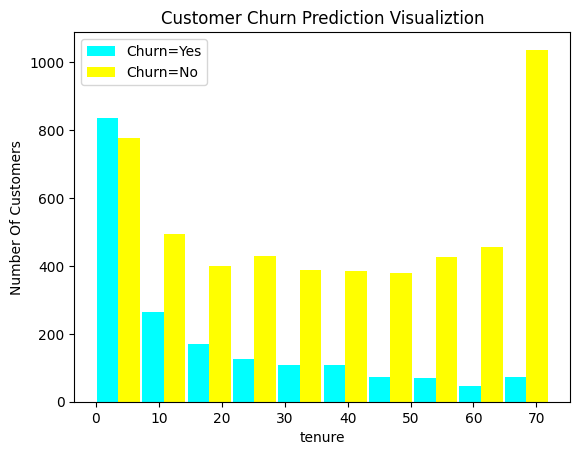

In [25]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['cyan','yellow'],label=['Churn=Yes','Churn=No'])
plt.legend()

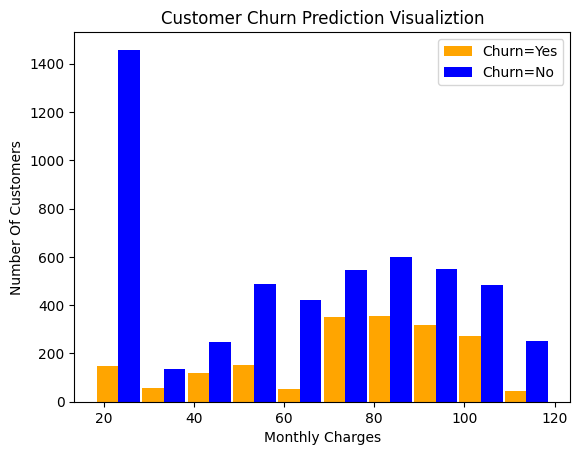

In [26]:
mc_churn_no = df1[df1.Churn=='No'].MonthlyCharges
mc_churn_yes = df1[df1.Churn=='Yes'].MonthlyCharges

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['orange','blue'],label=['Churn=Yes','Churn=No'])
plt.legend()

In [27]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}')

In [28]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [29]:
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)

In [30]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [31]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df1[col].replace({'Yes': 1,'No': 0},inplace=True)

In [32]:
for col in df1:
    print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [33]:
df1['gender'].replace({'Female':1,'Male':0},inplace=True)

In [34]:
df1.gender.unique()

array([1, 0], dtype=int64)

In [35]:
df1.gender.dtypes

dtype('int64')

In [36]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


One hot encoding

In [37]:
df2 = pd.get_dummies(data=df1, columns=['InternetService','Contract','PaymentMethod'])
df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [38]:
df2.shape

(7043, 27)

In [39]:
df2.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
285,1,0,0,0,22,1,1,0,0,0,...,0,1,0,0,1,0,0,1,0,0
3076,1,0,0,0,6,1,0,1,1,0,...,1,0,0,1,0,0,0,0,1,0
5036,1,1,1,0,16,1,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
1730,0,0,0,0,1,1,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
5621,1,0,1,0,3,1,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0


In [40]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          uint8
InternetService_Fiber optic                  uint8
InternetService_No             

In [41]:
cols_scale=['tenure','MonthlyCharges','TotalCharges']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_scale] = scaler.fit_transform(df2[cols_scale])

In [42]:
for cols in df2:
    print(f'{cols}: {df2[cols].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: 

In [43]:
col_bool=['InternetService_DSL','InternetService_Fiber optic', 'InternetService_No','Contract_Month-to-month','Contract_One year','Contract_Two year','PaymentMethod_Bank transfer (automatic)','PaymentMethod_Credit card (automatic)',
          'PaymentMethod_Electronic check','PaymentMethod_Mailed check']
for x in col_bool:
    df2[x].replace({True:1,False:0},inplace=True)

In [44]:
for col in df2:
    print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.01388889 0.47222222 0.02777778 0.625      0.11111111 0.30555556
 0.13888889 0.38888889 0.86111111 0.18055556 0.22222222 0.80555556
 0.68055556 0.34722222 0.95833333 0.72222222 0.98611111 0.29166667
 0.16666667 0.41666667 0.65277778 1.         0.23611111 0.375
 0.06944444 0.63888889 0.15277778 0.97222222 0.875      0.59722222
 0.20833333 0.83333333 0.25       0.91666667 0.125      0.04166667
 0.43055556 0.69444444 0.88888889 0.77777778 0.09722222 0.58333333
 0.48611111 0.66666667 0.40277778 0.90277778 0.52777778 0.94444444
 0.44444444 0.76388889 0.51388889 0.5        0.56944444 0.08333333
 0.05555556 0.45833333 0.93055556 0.31944444 0.79166667 0.84722222
 0.19444444 0.27777778 0.73611111 0.55555556 0.81944444 0.33333333
 0.61111111 0.26388889 0.75       0.70833333 0.36111111 0.
 0.54166667]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: 

In [45]:
df2.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          uint8
InternetService_Fiber optic                  uint8
InternetService_No             

## Split to test and train

In [46]:
x_churn=df2[df2.Churn==1]
x_nonchurn=df2[df2.Churn==0]
X = df2.drop('Churn',axis='columns')
y = df2['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=5)
x_churn=x_churn.drop('Churn',axis='columns')
x_nonchurn=x_nonchurn.drop('Churn',axis='columns')

In [47]:
print(type(df2))
print(type(x_churn))
print(type(x_nonchurn))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [48]:
X_train.shape

(5634, 26)

In [49]:
X_test.shape

(1409, 26)

In [50]:
X_train[:10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5860,1,0,0,0,0.027778,1,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
2458,0,1,1,0,0.694444,1,1,1,0,1,...,0,1,0,0,0,1,0,1,0,0
5879,0,0,1,0,0.458333,1,0,1,1,0,...,1,0,0,0,0,1,0,0,0,1
4708,1,0,1,1,0.777778,1,0,1,1,1,...,1,0,0,0,0,1,0,1,0,0
1293,0,0,1,1,0.930556,1,1,0,1,1,...,0,1,0,0,0,1,1,0,0,0
2242,0,0,1,1,0.611111,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
1444,0,0,0,1,0.569444,1,0,1,1,1,...,0,1,0,0,0,1,0,0,1,0
3269,0,0,0,0,0.902778,1,1,0,0,0,...,0,0,1,0,1,0,0,1,0,0
101,1,0,1,1,0.013889,1,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0
4191,1,0,1,0,0.875000,1,1,0,1,1,...,0,1,0,1,0,0,0,0,1,0


In [51]:
len(X_train.columns)

26

## Build an ANN

In [129]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping # Import the EarlyStopping callback

model = keras.Sequential([
    keras.layers.Dense(26, input_shape=(26,), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(15, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10) # Define the early_stopping callback

model.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.2, callbacks=[early_stopping])

D:\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6867 - loss: 0.9796 - val_accuracy: 0.7791 - val_loss: 0.7064
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7688 - loss: 0.7042 - val_accuracy: 0.7986 - val_loss: 0.5797
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7794 - loss: 0.5885 - val_accuracy: 0.7986 - val_loss: 0.5229
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7903 - loss: 0.5363 - val_accuracy: 0.8030 - val_loss: 0.4906
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7914 - loss: 0.5188 - val_accuracy: 0.8057 - val_loss: 0.4717
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8075 - loss: 0.4800 - val_accuracy: 0.8021 - val_loss: 0.4627
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7969 - loss: 0.4830 - val_accuracy: 0.7933 - val_loss: 0.4589
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7951 - loss: 0.4747 - val_accu

In [130]:
model.evaluate(X_test, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7700 - loss: 0.4621


[0.4501696825027466, 0.7870830297470093]

In [131]:
yp = model.predict(X_test)
yp[:5]

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.24881366],
       [0.50951385],
       [0.40561718],
       [0.6407385 ],
       [0.15837319]], dtype=float32)

In [132]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [133]:
y_pred[:10]

[0, 1, 0, 1, 0, 1, 0, 1, 0, 0]

In [134]:
y_test[:10]

4213    1
5035    0
3713    1
1720    0
234     0
4558    1
40      0
3455    1
5944    1
1089    0
Name: Churn, dtype: int64

In [135]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1023
           1       0.68      0.43      0.52       386

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409



Text(95.72222222222221, 0.5, 'True Values')

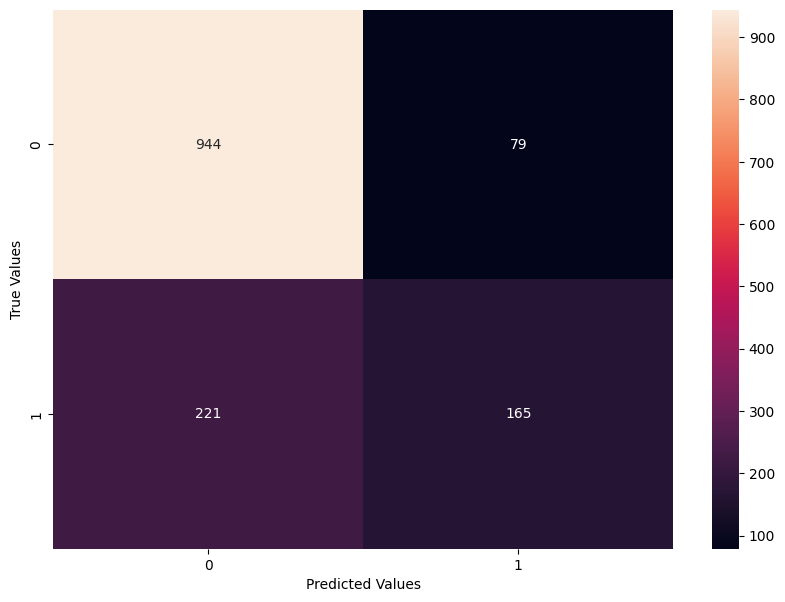

In [136]:
import seaborn as sn
from sklearn import metrics
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
cm1=cm.numpy()
tn, fp, fn, tp = cm1.ravel()
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')

In [137]:
y_test.shape

(1409,)

**Accuracy**

In [138]:
#Accuracy: ratio of accurate predictions to the total number of predictions.
accuracy=(tp+tn)/(tp+tn+fp+fn)
print(round(accuracy,2))

0.79


**Precision for 0 class. i.e. Precision for customers who did not churn**

In [139]:
precision_0=tn/(tn+fn)
print(precision_0)

0.8103004291845494


In [140]:
precision_1=tp/(tp+fp)
print(precision_1)

0.6762295081967213


In [141]:
#Specificity: ratio of the correctly classified non-churners to the total non-churners present in the dataset.
recall_0=tn/(tn+fp)
print(recall_0)

0.9227761485826002


In [142]:
#sensitivity:ratio of the correctly classified churners to the total churners present in the dataset.
recall_1=tp/(tp+fn)
print(recall_1)

0.4274611398963731


In [143]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1}")

F1 Score: 0.769996730960657


## Applying SMOTE

In [144]:
## Change to SMOTE
from imblearn.combine import SMOTEENN
from collections import Counter
st=SMOTEENN()
X_train_st,y_train_st = st.fit_resample(X_train, y_train)
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_st)))

The number of classes before fit Counter({0: 4151, 1: 1483})
The number of classes after fit Counter({1: 2871, 0: 2239})


In [145]:
# splitting the over sampling dataset
X_train_sap, X_test_sap, y_train_sap, y_test_sap = train_test_split(X_train_st, y_train_st, test_size=0.2)

In [146]:
print(type(X_train_sap))
print(X_train_sap.shape)
print(X_test_sap.shape)

<class 'pandas.core.frame.DataFrame'>
(4088, 26)
(1022, 26)


In [147]:
model_sap = keras.Sequential([
    keras.layers.Dense(26, input_shape=(26,), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(15, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model_sap.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping_sap = EarlyStopping(monitor='val_loss', patience=10) # Define the early_stopping callback

model_sap.fit(X_train_sap, y_train_sap, batch_size=32, epochs=100, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100


D:\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5805 - loss: 1.0726 - val_accuracy: 0.8851 - val_loss: 0.6806
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8494 - loss: 0.6494 - val_accuracy: 0.8961 - val_loss: 0.4600
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8797 - loss: 0.4914 - val_accuracy: 0.9144 - val_loss: 0.3829
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8901 - loss: 0.4249 - val_accuracy: 0.9156 - val_loss: 0.3408
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9046 - loss: 0.3685 - val_accuracy: 0.9120 - val_loss: 0.3189
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8966 - loss: 0.3485 - val_accuracy: 0.9144 - val_loss: 0.3025
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9053 - loss: 0.3292 - val_accuracy: 0.9156 - val_loss: 0.2914
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9047 - loss: 0.3185 - val_accuracy: 0.9181

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9219 - loss: 0.2522 - val_accuracy: 0.9132 - val_loss: 0.2298
Epoch 52/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9172 - loss: 0.2533 - val_accuracy: 0.9218 - val_loss: 0.2283
Epoch 53/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9146 - loss: 0.2514 - val_accuracy: 0.9218 - val_loss: 0.2312
Epoch 54/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9102 - loss: 0.2492 - val_accuracy: 0.9205 - val_loss: 0.2274
Epoch 55/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9100 - loss: 0.2658 - val_accuracy: 0.9230 - val_loss: 0.2270
Epoch 56/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9112 - loss: 0.2467 - val_accuracy: 0.9230 - val_loss: 0.2274
Epoch 57/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9098 - loss: 0.2445 - val_accuracy: 0.9144 - val_loss: 0.2328
Epoch 58/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9150 - loss: 0.2387 - val_accuracy:

In [148]:
model_sap.evaluate(X_test_sap, y_test_sap)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9218 - loss: 0.2329


[0.2354259341955185, 0.9187867045402527]

In [149]:
yp_sap = model_sap.predict(X_test_sap)
yp_sap[:5]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.037242  ],
       [0.3171582 ],
       [0.03595237],
       [0.9913785 ],
       [0.98986244]], dtype=float32)

In [150]:
y_pred_sap = [] # Initialize y_pred_sap
for element in yp_sap:
    if element > 0.5:
        y_pred_sap.append(1) # Append to y_pred_sap instead of y_pred
    else:
        y_pred_sap.append(0) # Append to y_pred_sap instead of y_pred

In [151]:
y_pred_sap[:10]

[0, 0, 0, 1, 1, 0, 1, 0, 0, 0]

In [152]:
y_test_sap[:10]

2184    0
1051    0
2000    0
4139    1
2357    1
306     0
4577    1
789     0
1353    0
192     0
Name: Churn, dtype: int64

In [153]:
print(yp_sap.shape)
print(X_test.shape)

(1022, 1)
(1409, 26)


In [154]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test_sap,y_pred_sap))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       433
           1       0.93      0.92      0.93       589

    accuracy                           0.92      1022
   macro avg       0.92      0.92      0.92      1022
weighted avg       0.92      0.92      0.92      1022



Text(70.72222222222221, 0.5, 'True Values')

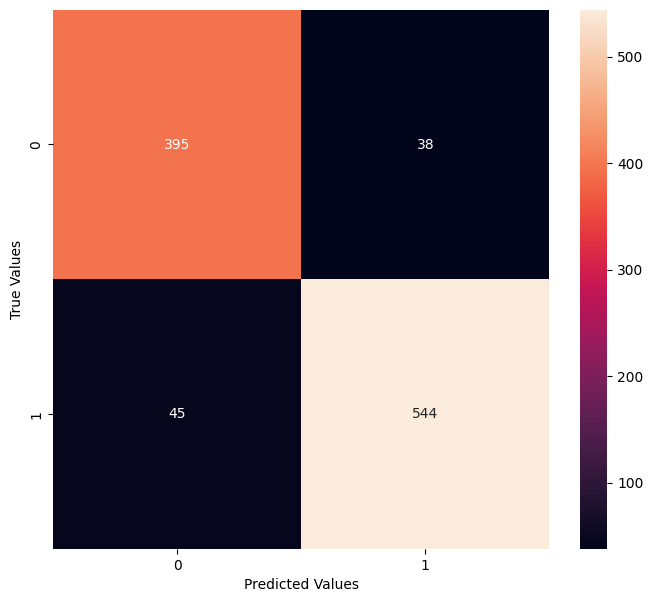

In [155]:
import seaborn as sn
from sklearn import metrics
cm_sap = tf.math.confusion_matrix(labels=y_test_sap,predictions=y_pred_sap)
cm1_sap=cm_sap.numpy()
tn1, fp1, fn1, tp1 = cm1_sap.ravel()
plt.figure(figsize = (8,7))
sn.heatmap(cm_sap, annot=True, fmt='d')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')

In [156]:
y_test_sap.shape

(1022,)

In [157]:
#Accuracy: ratio of accurate predictions to the total number of predictions.
acc1=(tp1+tn1)/(tp1+tn1+fp1+fn1)
print(round(acc1,2))

0.92


In [158]:
prec1_0=tn1/(tn1+fn1)
print(prec1_0)

0.8977272727272727


In [159]:
prec1_1=tp1/(tp1+fp1)
print(prec1_1)

0.9347079037800687


In [160]:
recall1_1=tp1/(tp1+fn1)
print(recall1_1)

0.9235993208828522


In [161]:
recall1_0=tn1/(tn1+fp1)
print(recall1_0)

0.9122401847575058


In [162]:
from sklearn.metrics import f1_score
f1_sp = f1_score(y_test_sap, y_pred_sap, average='weighted')
print(f"F1 Score: {f1_sp}")

F1 Score: 0.9188695518887655


## Data Explainability

### Protodash

In [163]:
#!python3 -m venv myenv
#source myenv/bin/activate  # for Windows use `myenv\Scripts\activate`
#pip install pandas==1.3.5 aix360


In [164]:
from aix360.algorithms.protodash import ProtodashExplainer

**Computing prototypes for churn and non-churn**

In [165]:
explainer = ProtodashExplainer()


In [166]:
m = 10
xchurn = x_churn.to_numpy()
xnonchurn = x_nonchurn.to_numpy()
(W_churn, S_churn, _) = explainer.explain(xchurn, xchurn, m=m)
(W_nonchurn, S_nonchurn, _) = explainer.explain(xnonchurn, xnonchurn, m=m)

In [167]:
# get prototypes from index
df_churn_prototypes = x_churn.iloc[S_churn].copy()
df_nonchurn_prototypes = x_nonchurn.iloc[S_nonchurn].copy()

#normalize weights
W_churn = np.around(W_churn/np.sum(W_churn), 2)
W_nonchurn = np.around(W_nonchurn/np.sum(W_nonchurn), 2)

In [168]:
print("Churn prototypes with weights:")
print("----------------------------")
for i in range(m):
    print(W_churn[i], df_churn_prototypes.iloc[i])

Churn prototypes with weights:
----------------------------
0.33 gender                                     1.000000
SeniorCitizen                              0.000000
Partner                                    1.000000
Dependents                                 0.000000
tenure                                     0.472222
PhoneService                               1.000000
MultipleLines                              1.000000
OnlineSecurity                             0.000000
OnlineBackup                               0.000000
DeviceProtection                           0.000000
TechSupport                                0.000000
StreamingTV                                1.000000
StreamingMovies                            1.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.790050
TotalCharges                               0.367961
InternetService_DSL                        0.000000
InternetService_Fiber optic                1.000000

In [169]:
print("Non-Churn prototypes with weights:")
print("----------------------------")
for i in range(m):
    print(W_nonchurn[i], df_nonchurn_prototypes.iloc[i])

Non-Churn prototypes with weights:
----------------------------
0.17 gender                                     1.000000
SeniorCitizen                              0.000000
Partner                                    1.000000
Dependents                                 1.000000
tenure                                     1.000000
PhoneService                               1.000000
MultipleLines                              1.000000
OnlineSecurity                             1.000000
OnlineBackup                               1.000000
DeviceProtection                           1.000000
TechSupport                                1.000000
StreamingTV                                1.000000
StreamingMovies                            1.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.746269
TotalCharges                               0.769692
InternetService_DSL                        1.000000
InternetService_Fiber optic                0.00

In [170]:
k = 0
sample_text = x_churn.iloc[k]
sample_vec = xchurn[k]
sample_vec = sample_vec.reshape(1, sample_vec.shape[0])

In [171]:
print(sample_text)

gender                                     0.000000
SeniorCitizen                              0.000000
Partner                                    0.000000
Dependents                                 0.000000
tenure                                     0.027778
PhoneService                               1.000000
MultipleLines                              0.000000
OnlineSecurity                             1.000000
OnlineBackup                               1.000000
DeviceProtection                           0.000000
TechSupport                                0.000000
StreamingTV                                0.000000
StreamingMovies                            0.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.354229
TotalCharges                               0.010310
InternetService_DSL                        1.000000
InternetService_Fiber optic                0.000000
InternetService_No                         0.000000
Contract_Mon

In [172]:
print(sample_vec.shape)

(1, 26)


In [173]:
x_churn_other = xchurn[np.arange(xchurn.shape[0]) != k, :]
xChurn_other = x_churn.iloc[np.arange(xchurn.shape[0]) != k].copy()

In [174]:
# Take a sample spam text and find samples similar to it.
(W1_churn, S1_churn, _) = explainer.explain(sample_vec, x_churn_other, m=m)

In [175]:
#normalize weights
W1_churn = np.around(W1_churn/np.sum(W1_churn), 2)

In [176]:
S1_churn

array([1856,  589, 1855,  659, 1590,  980,  700,   58,  565,  884])

In [177]:
# similar Churn prototypes
print("original")
print("-------------")
print(sample_text)
print("")

print("Similar churn prototypes:")
print("------------------------")
m = 10
for i in range(m):
    print(W1_churn[i], xChurn_other.iloc[S1_churn[i]])

original
-------------
gender                                     0.000000
SeniorCitizen                              0.000000
Partner                                    0.000000
Dependents                                 0.000000
tenure                                     0.027778
PhoneService                               1.000000
MultipleLines                              0.000000
OnlineSecurity                             1.000000
OnlineBackup                               1.000000
DeviceProtection                           0.000000
TechSupport                                0.000000
StreamingTV                                0.000000
StreamingMovies                            0.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.354229
TotalCharges                               0.010310
InternetService_DSL                        1.000000
InternetService_Fiber optic                0.000000
InternetService_No                       

In [229]:
print("Similar Non churn prototypes:")
print("------------------------")
m = 10
for i in range(m):
    print(W1_nonchurn[i], xNonChurn_other.iloc[S1_nonchurn[i]])

Similar Non churn prototypes:
------------------------
0.09 gender                                     0.000000
SeniorCitizen                              0.000000
Partner                                    1.000000
Dependents                                 1.000000
tenure                                     0.777778
PhoneService                               1.000000
MultipleLines                              1.000000
OnlineSecurity                             0.000000
OnlineBackup                               1.000000
DeviceProtection                           0.000000
TechSupport                                1.000000
StreamingTV                                1.000000
StreamingMovies                            0.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.783085
TotalCharges                               0.624671
InternetService_DSL                        0.000000
InternetService_Fiber optic                1.000000
Inte

In [178]:
k = 3
sample_text = x_nonchurn.iloc[k]
sample_vec = xnonchurn[k]
sample_vec = sample_vec.reshape(1, sample_vec.shape[0])

In [179]:
print(sample_text)
print(sample_vec.shape)

gender                                     0.000000
SeniorCitizen                              0.000000
Partner                                    0.000000
Dependents                                 1.000000
tenure                                     0.305556
PhoneService                               1.000000
MultipleLines                              1.000000
OnlineSecurity                             0.000000
OnlineBackup                               1.000000
DeviceProtection                           0.000000
TechSupport                                0.000000
StreamingTV                                1.000000
StreamingMovies                            0.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.704975
TotalCharges                               0.222779
InternetService_DSL                        0.000000
InternetService_Fiber optic                1.000000
InternetService_No                         0.000000
Contract_Mon

In [180]:
x_nonchurn_other = xnonchurn[np.arange(xnonchurn.shape[0]) != k, :]
xNonChurn_other = x_nonchurn.iloc[np.arange(xnonchurn.shape[0]) != k].copy()

In [181]:
# Take a sample instance and find samples similar to it.
(W1_nonchurn, S1_nonchurn, _) = explainer.explain(sample_vec, x_nonchurn_other, m=m)

In [182]:
#normalize weights
W1_nonchurn = np.around(W1_nonchurn/np.sum(W1_nonchurn), 2)

In [183]:
S1_nonchurn

array([3352,   63, 1567, 3182, 5131, 2058,  153,  677, 4682,  225])

In [184]:
# similar Non-churn prototypes
print("original")
print("-------------")
print(sample_text)
print("")

print("Similar Non churn prototypes:")
print("------------------------")
m = 10
for i in range(m):
    print(W1_nonchurn[i], xNonChurn_other.iloc[S1_nonchurn[i]])

original
-------------
gender                                     0.000000
SeniorCitizen                              0.000000
Partner                                    0.000000
Dependents                                 1.000000
tenure                                     0.305556
PhoneService                               1.000000
MultipleLines                              1.000000
OnlineSecurity                             0.000000
OnlineBackup                               1.000000
DeviceProtection                           0.000000
TechSupport                                0.000000
StreamingTV                                1.000000
StreamingMovies                            0.000000
PaperlessBilling                           1.000000
MonthlyCharges                             0.704975
TotalCharges                               0.222779
InternetService_DSL                        0.000000
InternetService_Fiber optic                1.000000
InternetService_No                       

## Model Explainability

In [187]:
X_train_sap.shape

(4088, 26)

In [188]:
y_train_sap.shape

(4088,)

In [189]:
feature_names = df2.columns[:-1].tolist() 

In [190]:
feature_names

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check']

In [191]:
class_names = ["Churn", "Non-Churn"]

### Shap

In [196]:
import shap

In [197]:
# Print the shapes of X_train and X_test to understand their structure
print("Shape of X_train:", X_train_sap.shape)
print("Shape of X_test:", X_test_sap.shape)

Shape of X_train: (4088, 26)
Shape of X_test: (1022, 26)


In [198]:
feature_names = df2.columns[:-1].tolist()

In [199]:
# Reduce the size of the background to speed up SHAP computation
background_indices = np.random.choice(X_train_sap.shape[0], 25, replace=False)  # Randomly choose 25 indices
background = X_train_sap.iloc[background_indices]  # Use iloc to select rows based on indices


In [200]:
# Choose a larger subset size (e.g., 500 or more) from the test set
subset_size = 500  
# Randomly choose indices and use .iloc to select rows
X_test_subset = X_test_sap.iloc[np.random.choice(X_test_sap.shape[0], subset_size, replace=False)]


In [201]:
# Use KernelExplainer for SHAP
explainer = shap.KernelExplainer(model_sap, background)


In [202]:
# Get SHAP values for the selected subset of the test set
shap_values = explainer.shap_values(X_test_subset)


  0%|          | 0/500 [00:00<?, ?it/s]

SHAP values shape: (500, 26, 1)
X_test_subset shape: (500, 26)


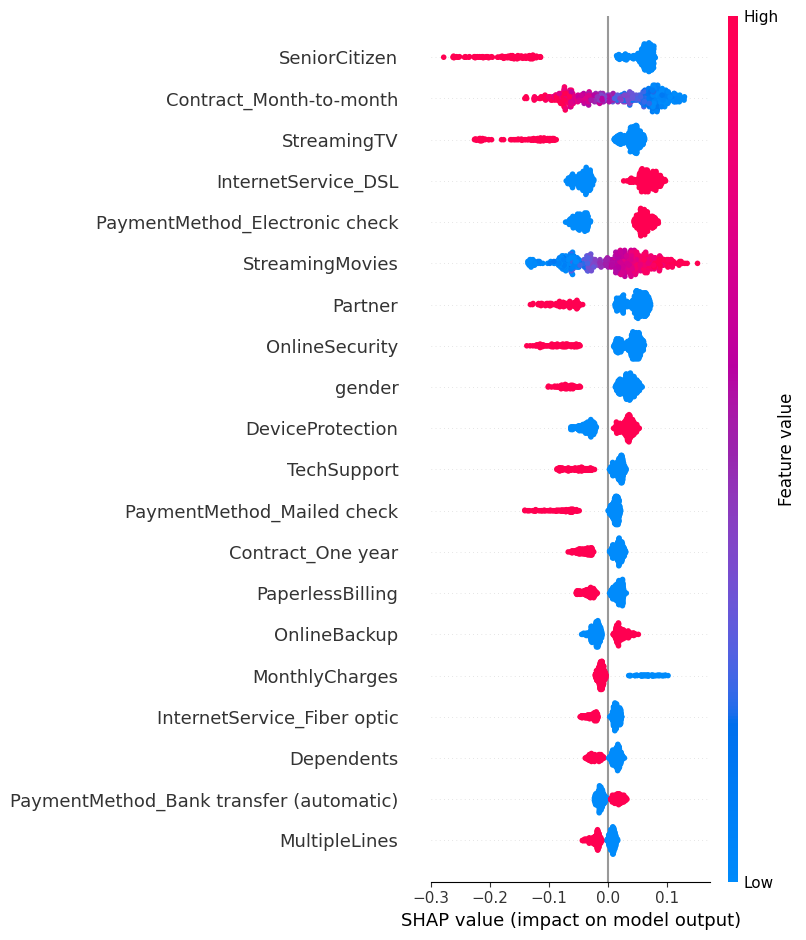

In [228]:
# Print shapes for debugging
print("SHAP values shape:", shap_values.shape)  # (500, 26, 1)
print("X_test_subset shape:", X_test_subset.shape)  # (500, 26)

# Squeeze the SHAP values to remove the singleton dimension
shap_values_squeezed = np.squeeze(shap_values)  # Now it should be (500, 26)

# Now plot SHAP summary plot
shap.summary_plot(shap_values_squeezed, X_test_subset, feature_names=feature_names)


In [204]:
shap.initjs()

In [206]:
# Ensure SHAP values and features are NumPy arrays
shap_values_array = np.squeeze(shap_values)  # Shape should be (500, 26)
X_test_subset_array = X_test_subset.values if isinstance(X_test_subset, pd.DataFrame) else X_test_subset

# Now access the first instance and the corresponding SHAP values
shap_value_instance = shap_values_array[0, :]  # This gives the SHAP values for the first instance
feature_instance = X_test_subset_array[0, :]  # This gives the features for the first instance

# Force plot for the first instance
shap.force_plot(explainer.expected_value[0], shap_value_instance, feature_names)


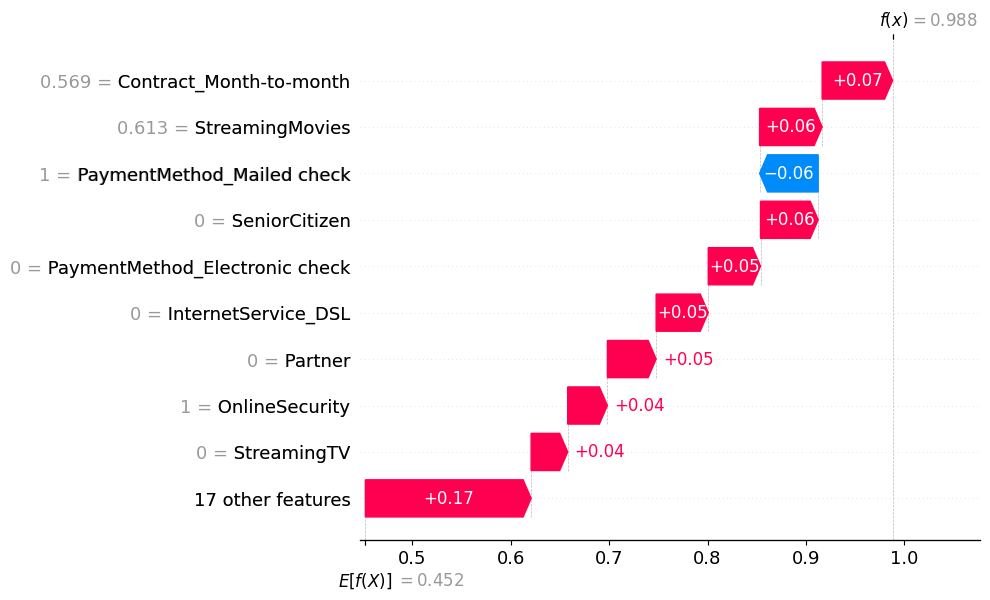

In [222]:
# Create a SHAP Explanation object for the ith instance
shap_exp = shap.Explanation(
        values=shap_values[5, :, 0],  # Access all features for the 25th instance
        base_values=explainer.expected_value[0],  # Base value for the first class (or appropriate class)
        data=X_test_sap.iloc[5],  # Data for the ith instance
        feature_names=feature_names
    )
shap.waterfall_plot(shap_exp, max_display=10)

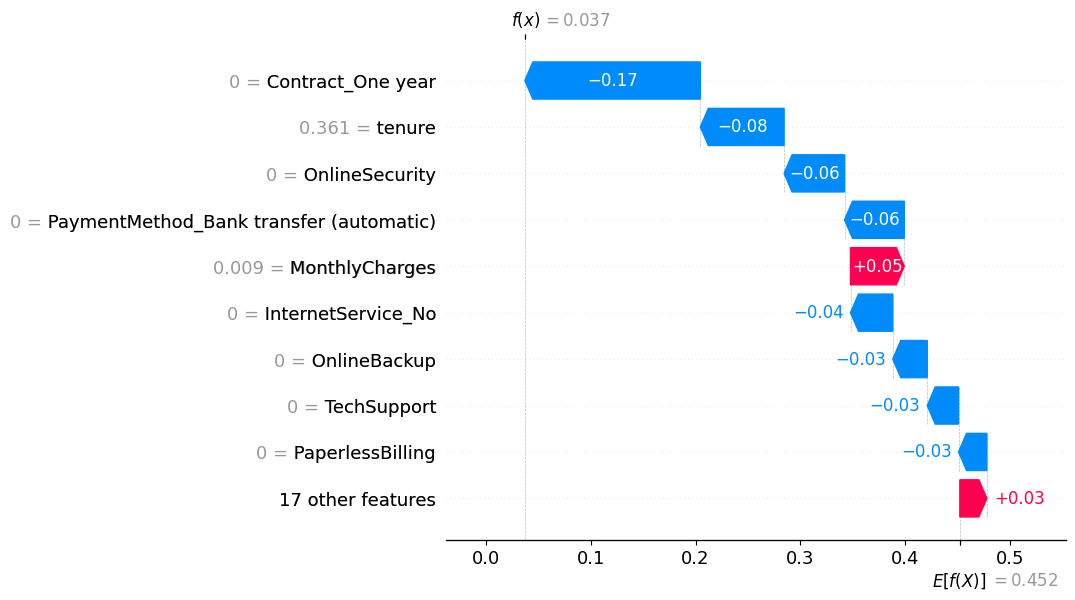

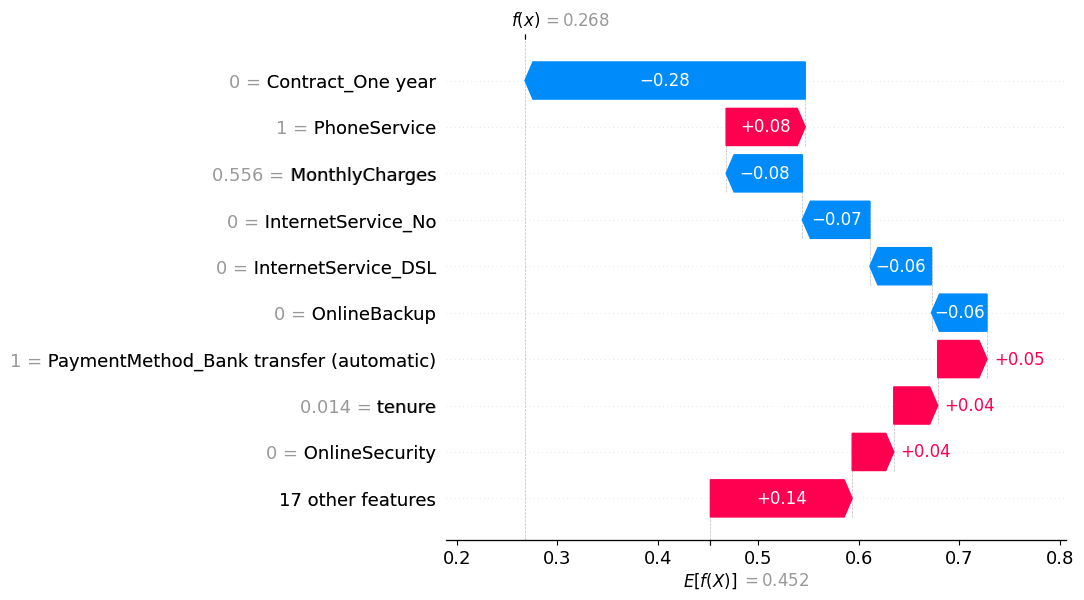

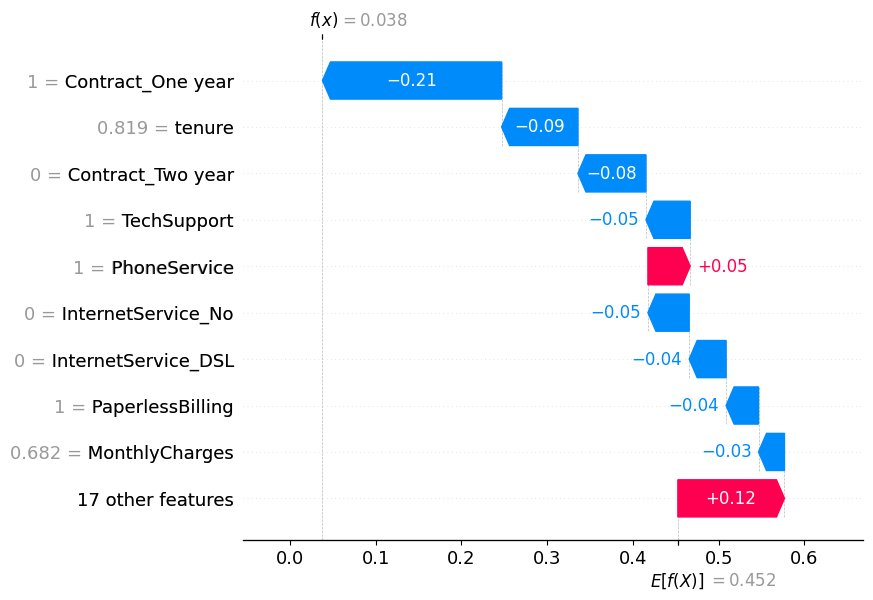

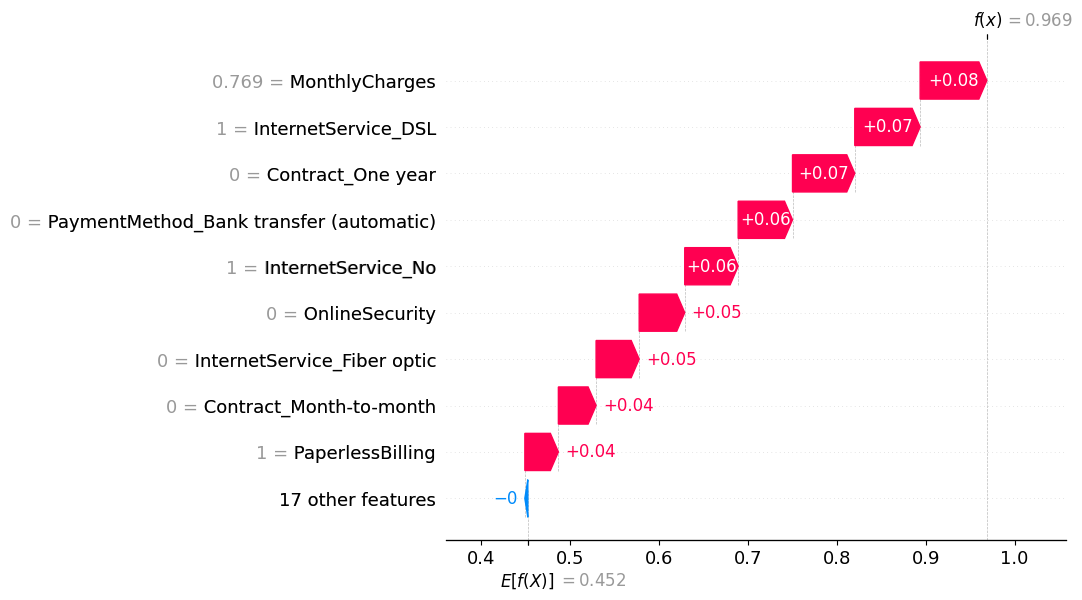

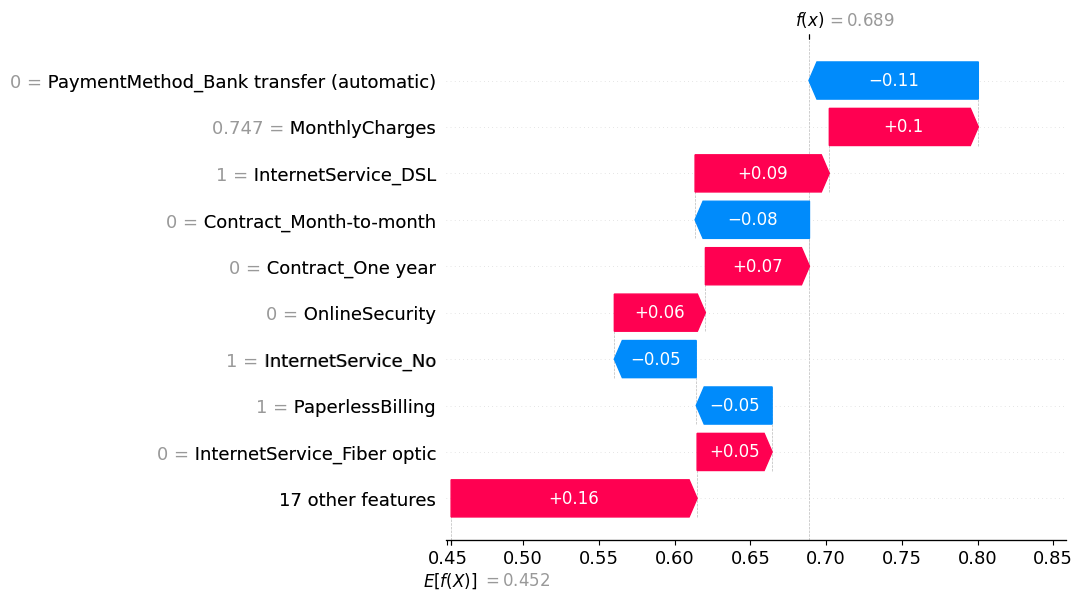

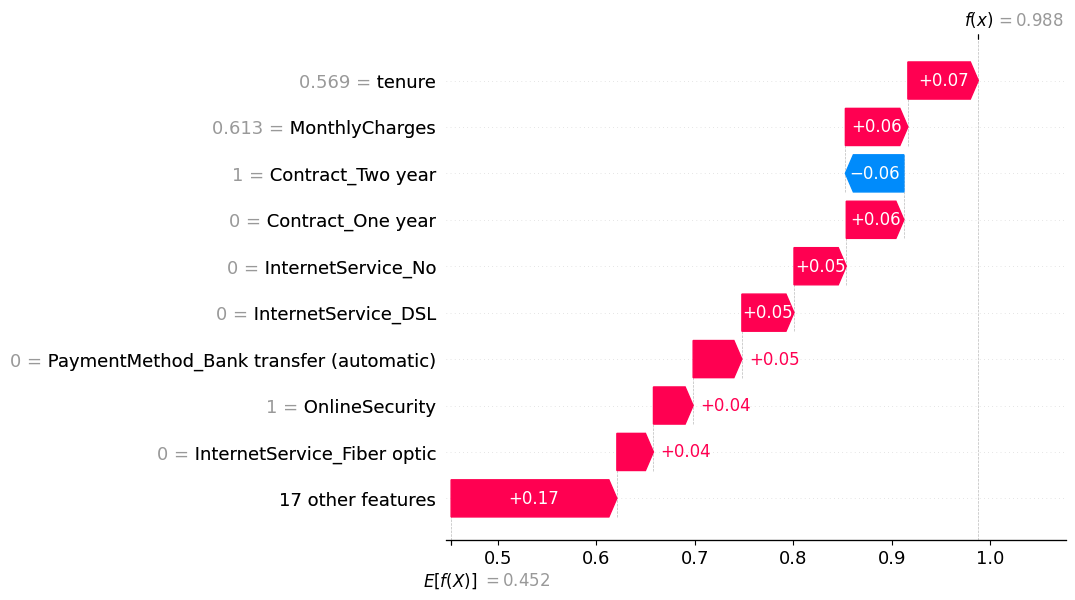

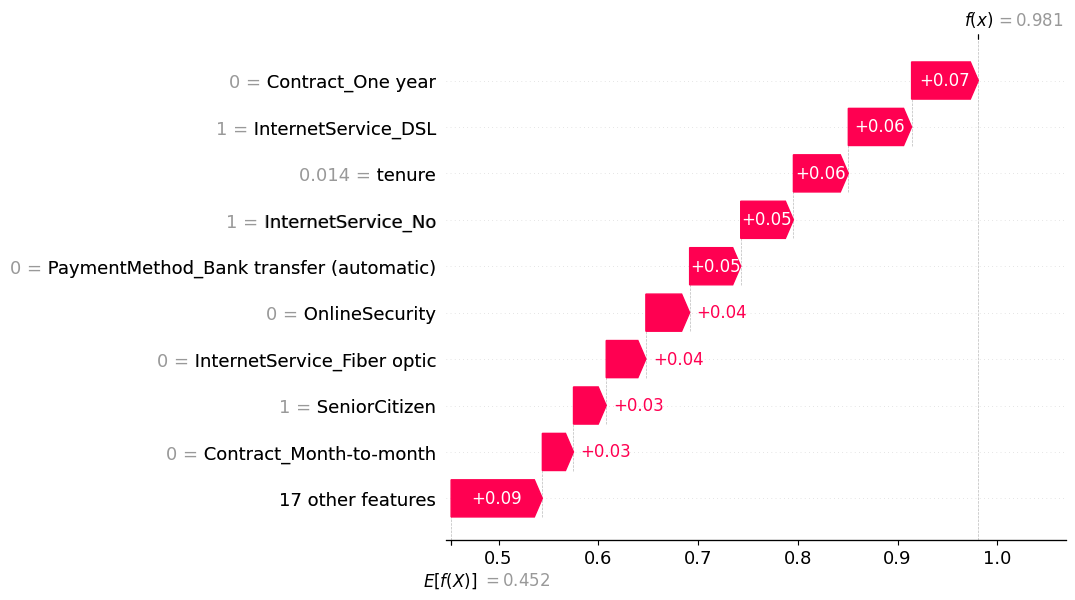

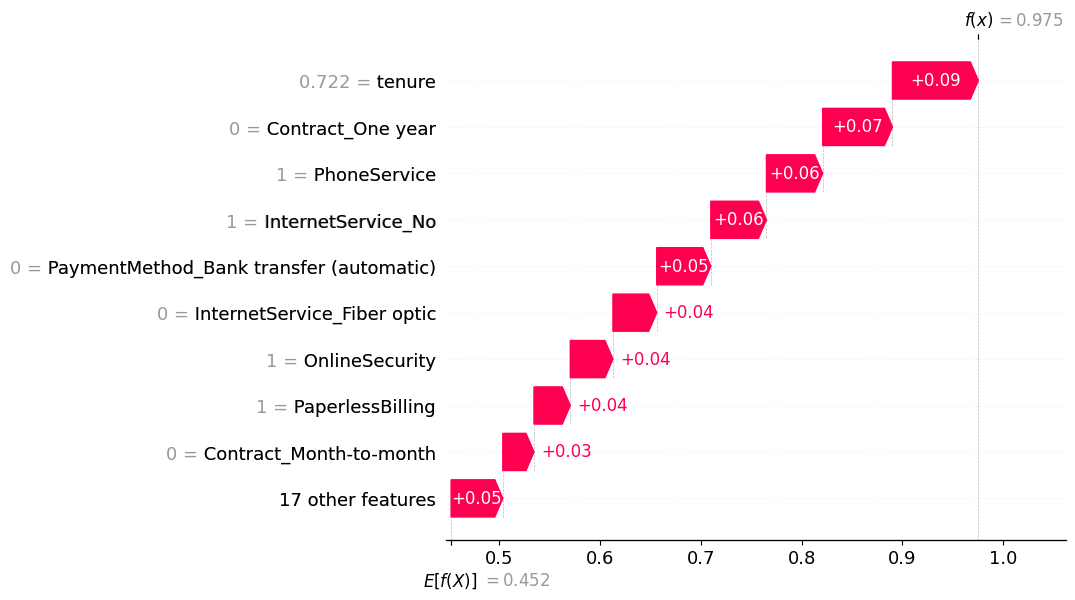

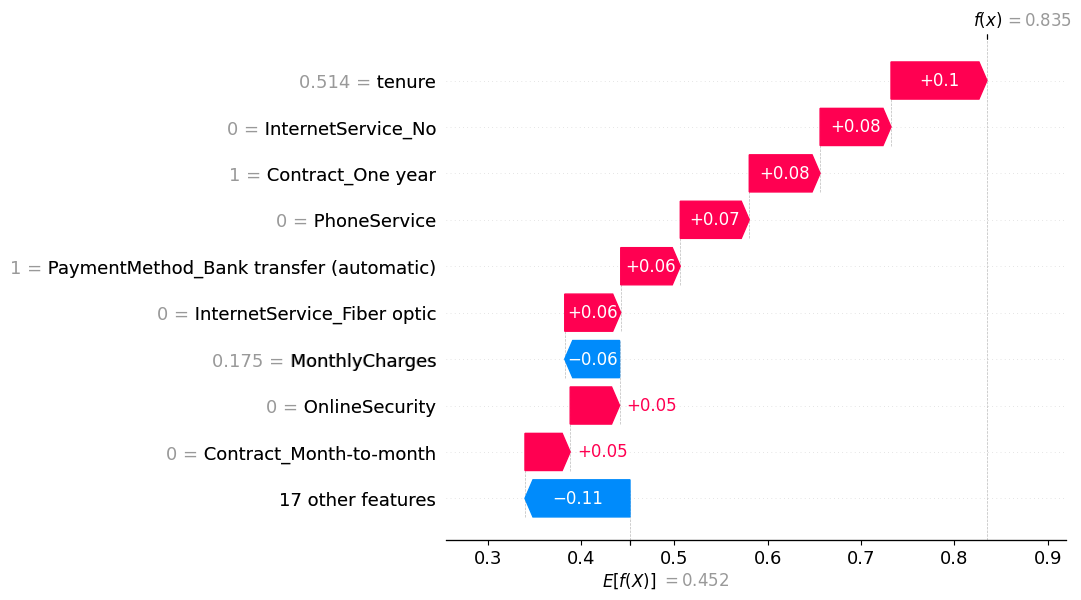

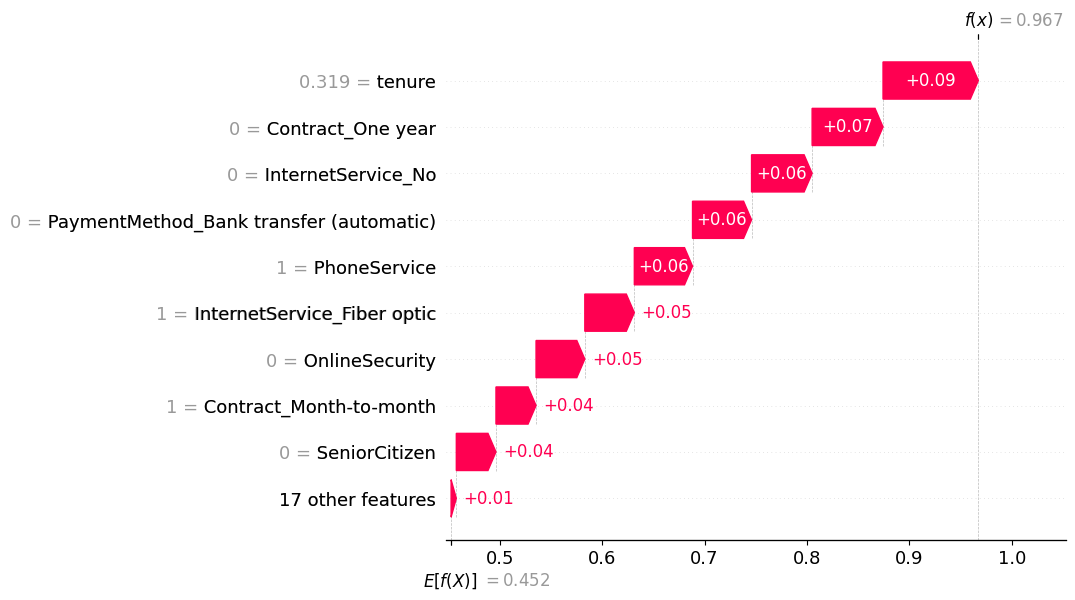

In [208]:
# Loop over each instance in the test set
for i in range(10):
    # Create a SHAP Explanation object for the ith instance
    shap_exp = shap.Explanation(
        values=shap_values[i, :, 0],  # Access all features for the ith instance
        base_values=explainer.expected_value[0],  # Base value for the first class (or appropriate class)
        data=X_test_sap.iloc[i],  # Data for the ith instance
        feature_names=feature_names
    )
    
    # Generate the waterfall plot for the current instance
    shap.waterfall_plot(shap_exp, max_display= 10)
    plt.show()

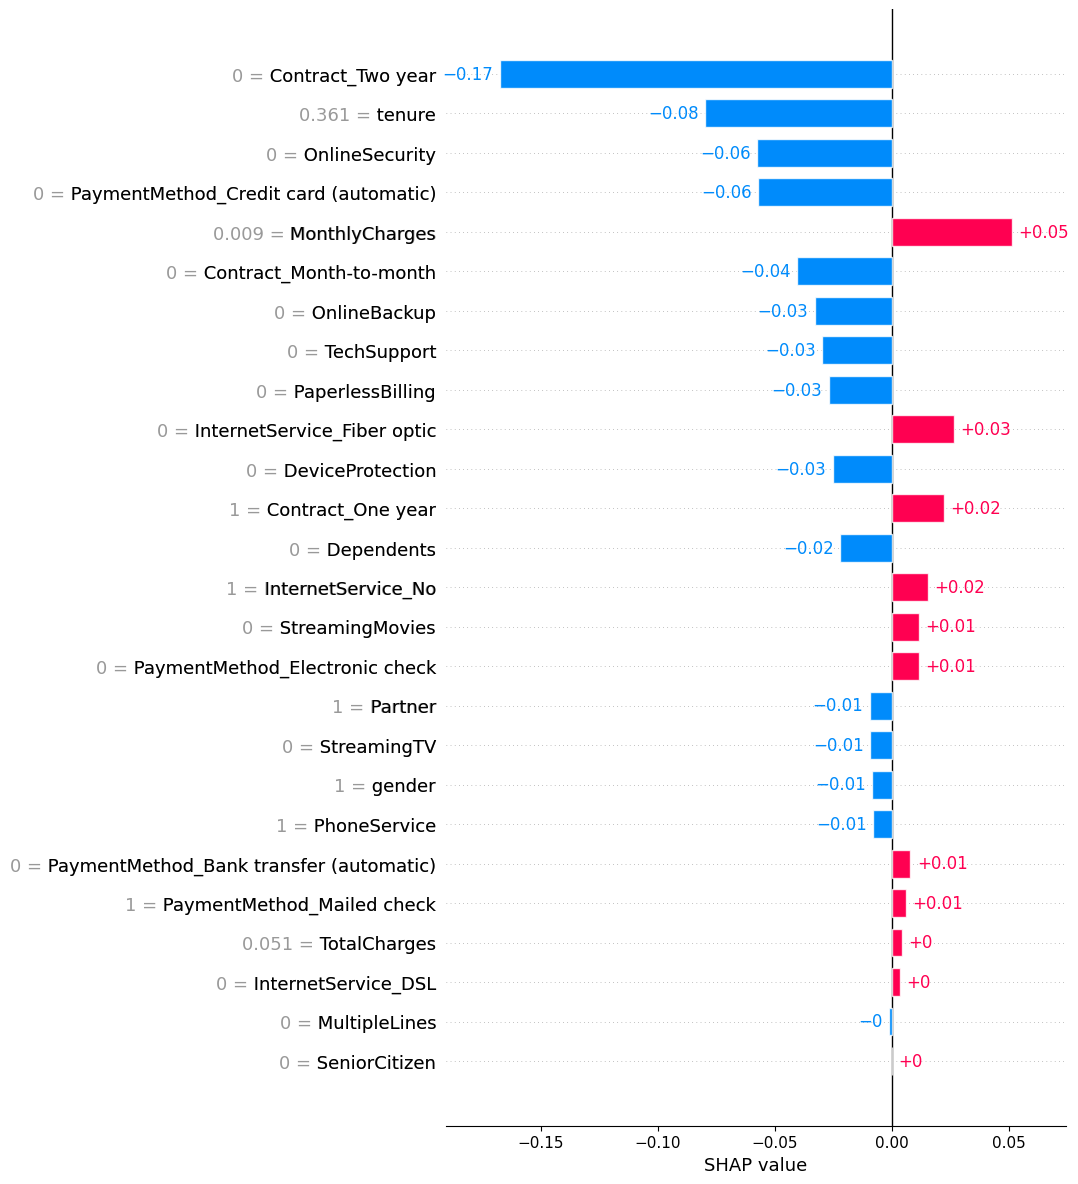

In [223]:
# Create a SHAP Explanation object for the ith instance
shap_exp = shap.Explanation(
        values=shap_values[0, :, 0],  # Access all features for the ith instance
        base_values=explainer.expected_value[0],  # Base value for the first class (or appropriate class)
        data=X_test_sap.iloc[0],  # Data for the ith instance
        feature_names=X_test_subset.columns.tolist()
    )
shap.plots.bar(shap_exp, max_display=len(X_test_subset.columns.tolist()))

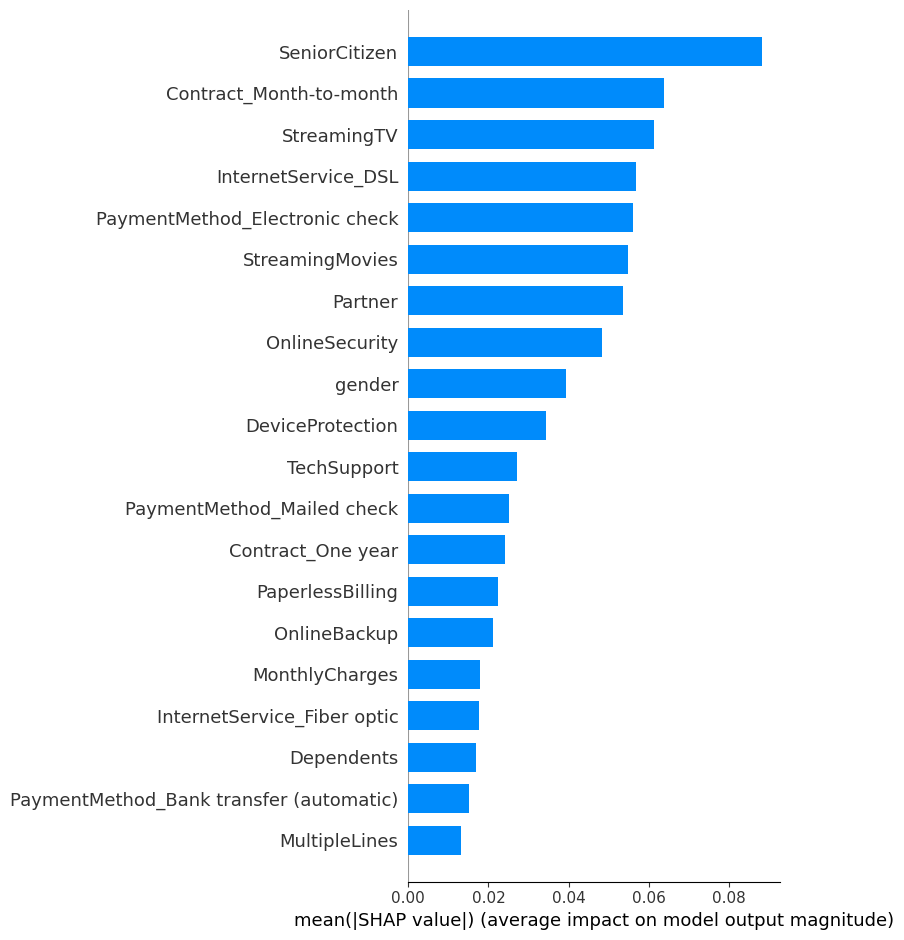

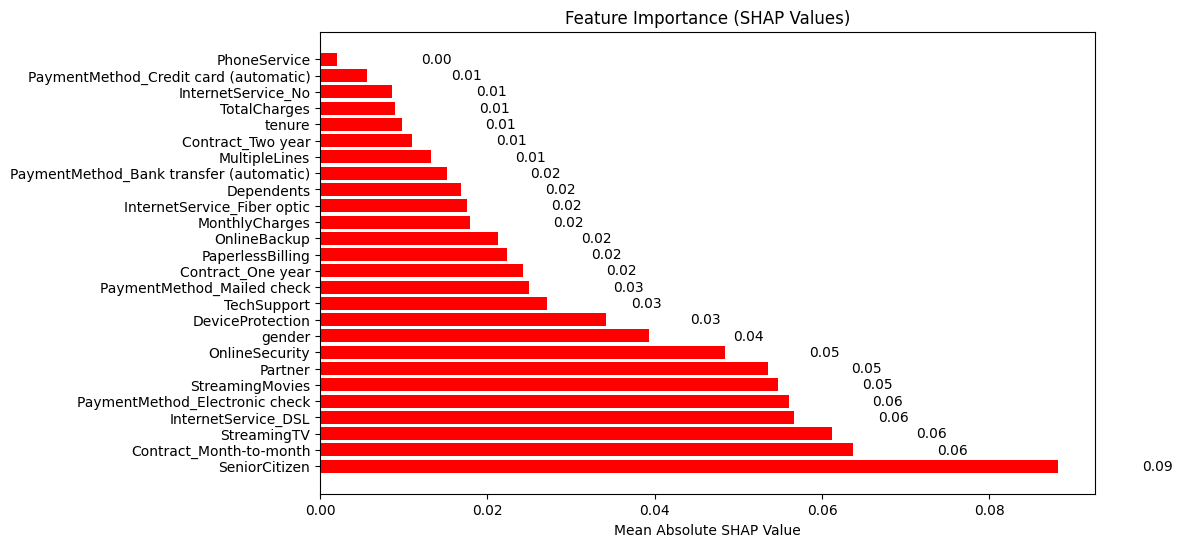

In [214]:
# First, generate the SHAP summary bar plot
shap.summary_plot(shap_values_squeezed, X_test_subset, feature_names=feature_names, plot_type="bar")

# Extract mean absolute SHAP values for each feature
mean_shap_values = np.abs(shap_values_squeezed).mean(axis=0)

# Sort the feature importances in descending order
sorted_indices = np.argsort(mean_shap_values)[::-1]

# Get sorted feature names and SHAP values
sorted_feature_names = [feature_names[i] for i in sorted_indices]
sorted_shap_values = mean_shap_values[sorted_indices]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_feature_names, sorted_shap_values, color="red")

# Annotate each bar with its SHAP value
for bar, value in zip(bars, sorted_shap_values):
    plt.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f'{value:.2f}', va='center')

# Display the plot
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Feature Importance (SHAP Values)")
plt.show()

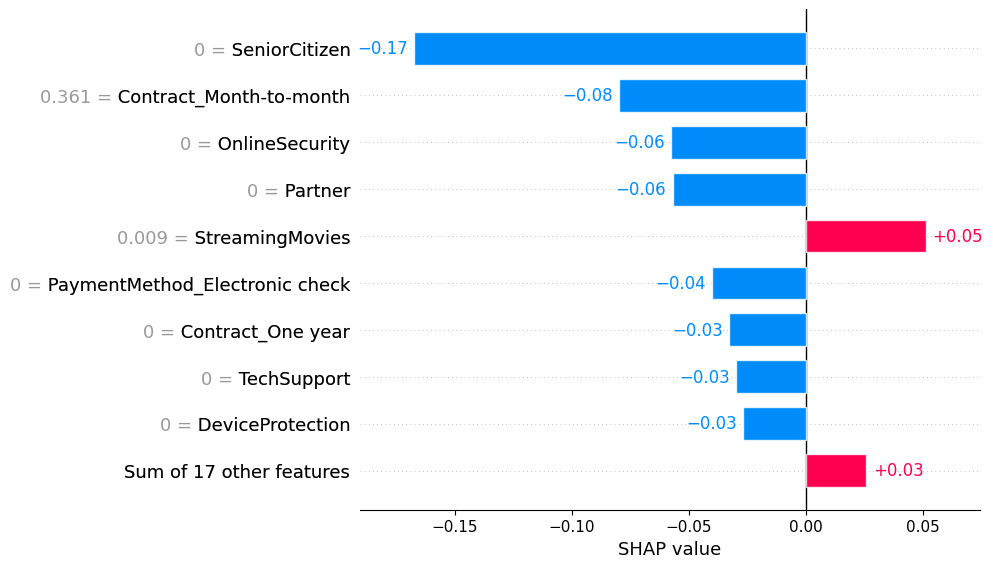

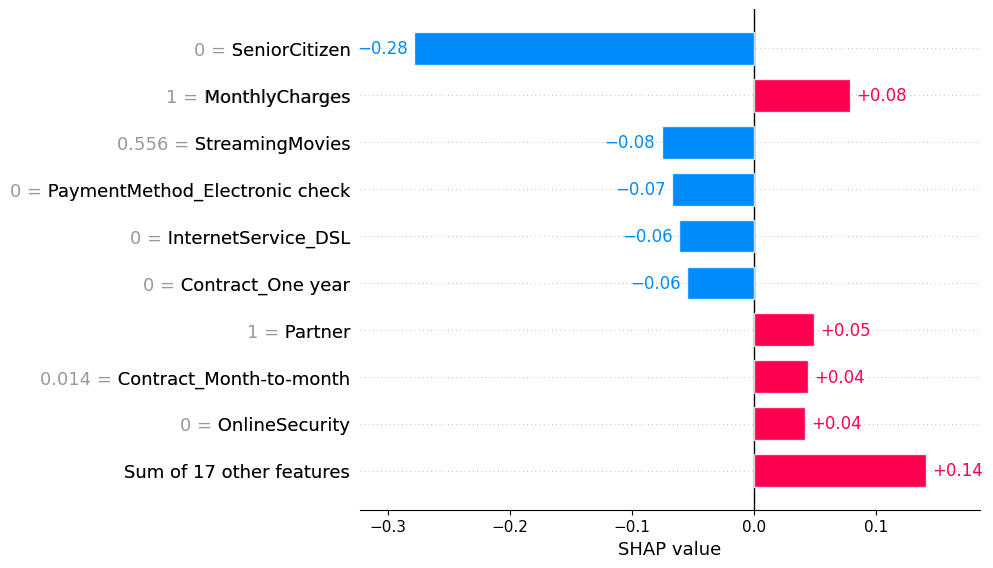

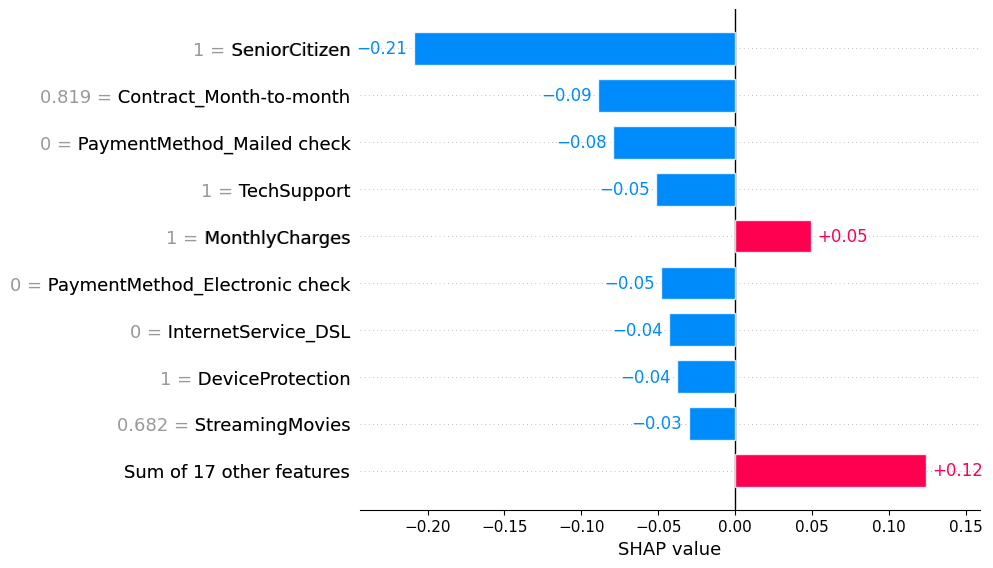

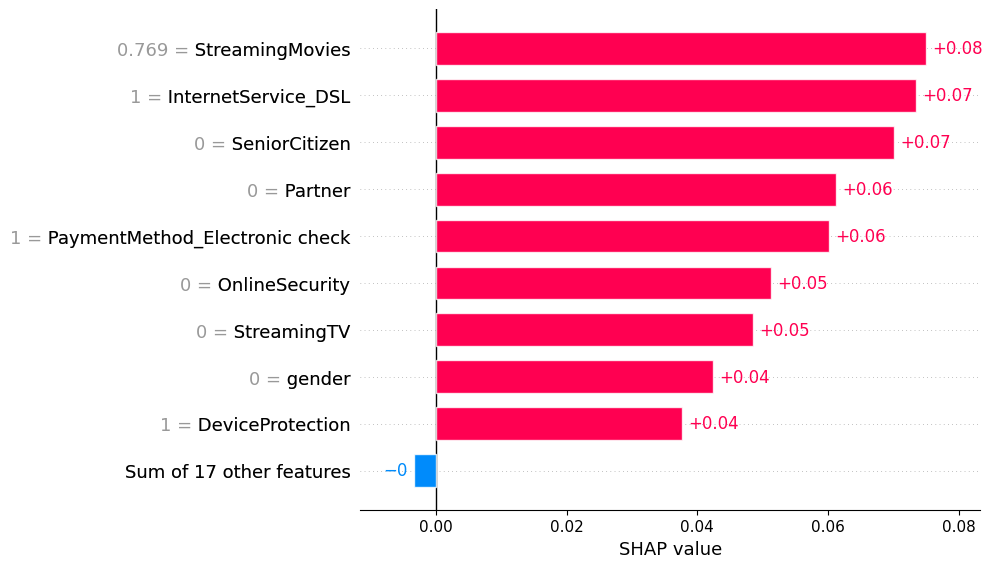

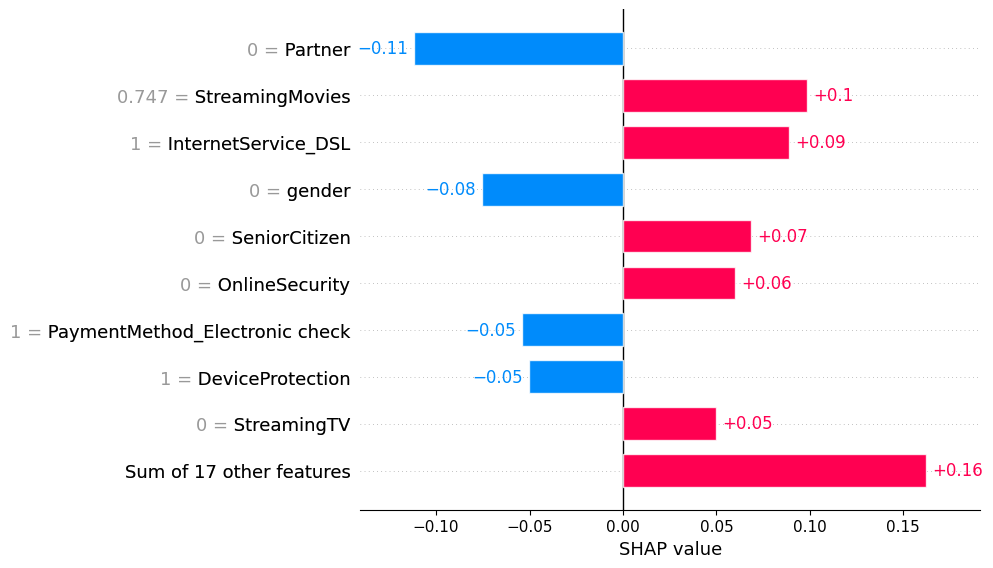

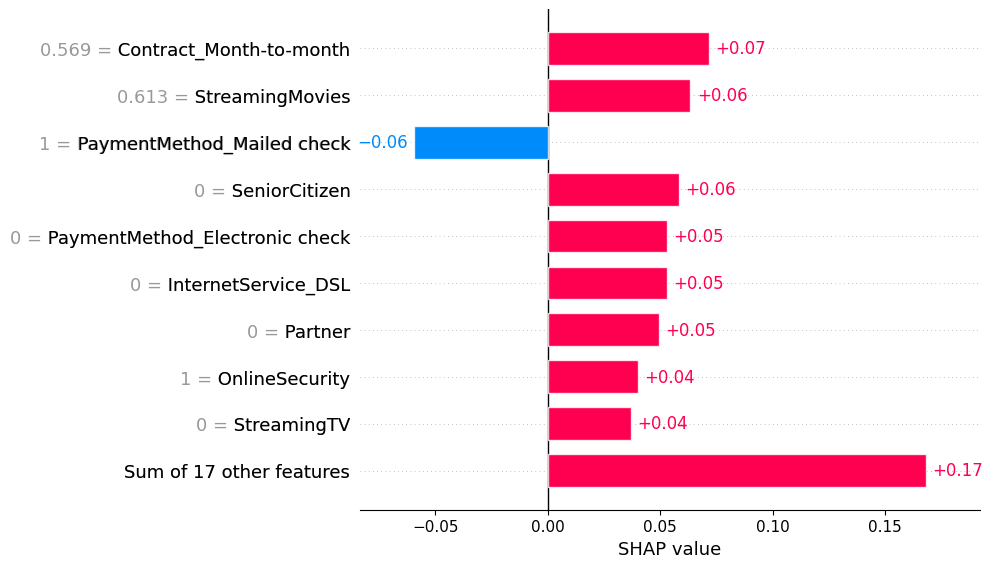

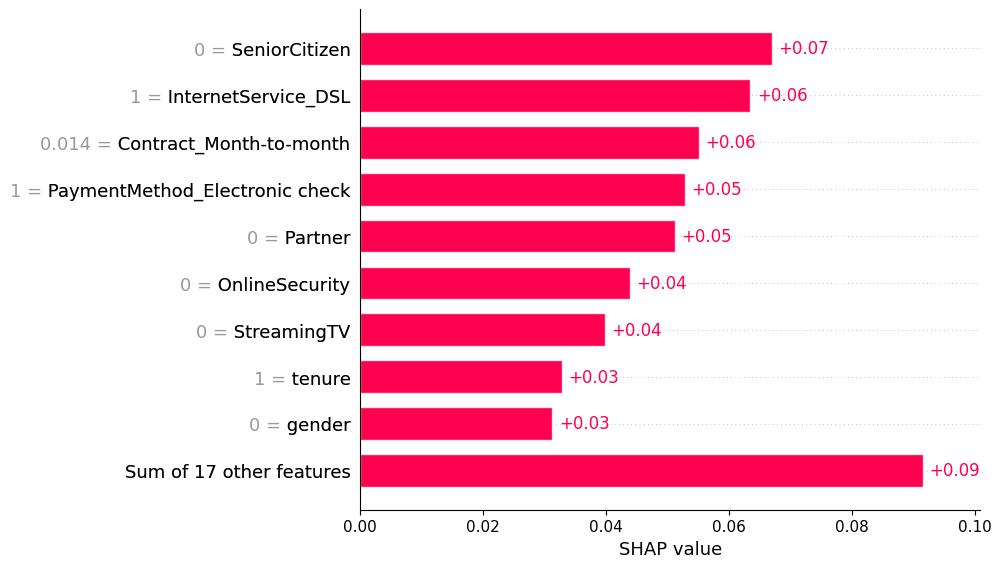

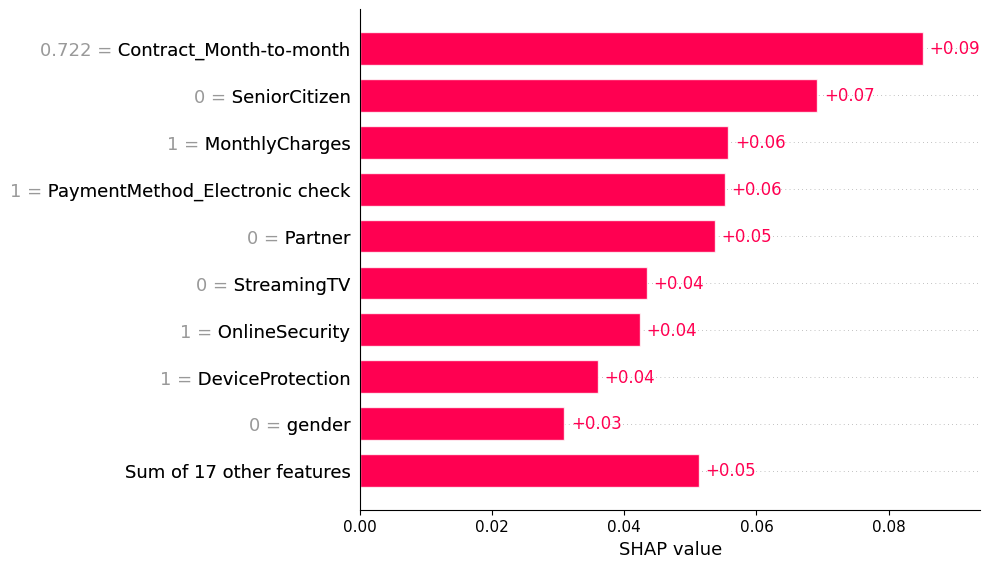

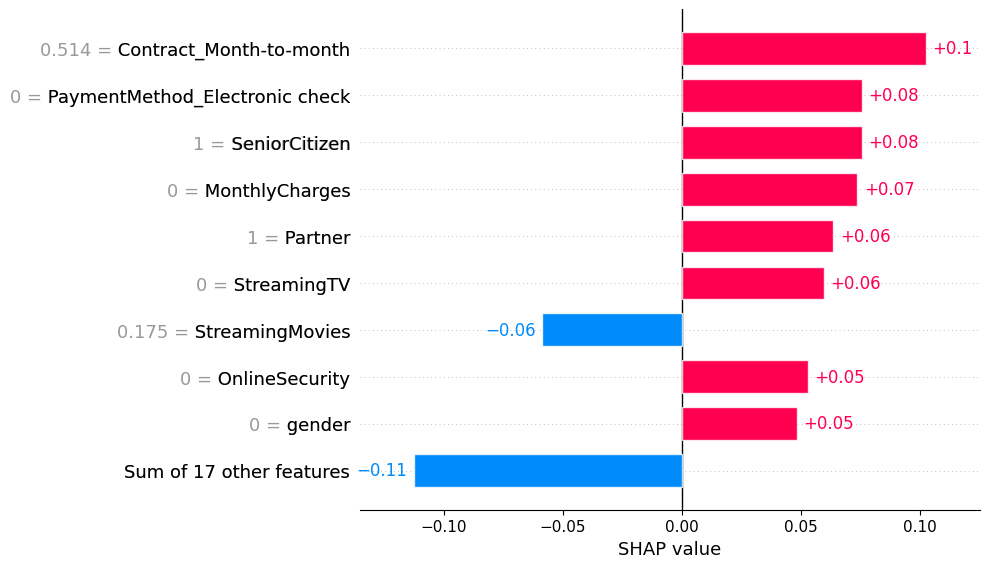

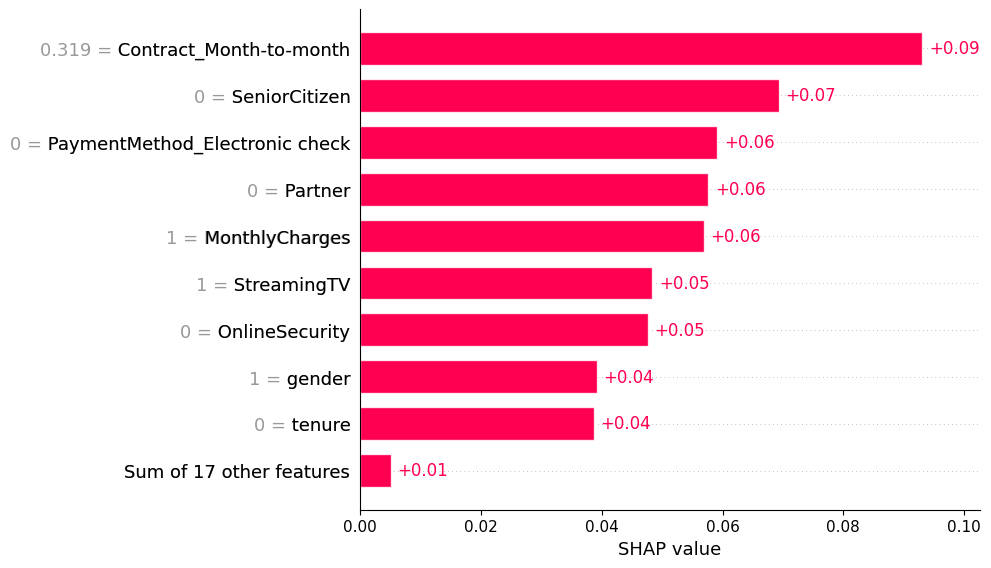

In [216]:
# Loop over each instance in the test set
for i in range(10):
    # Create a SHAP Explanation object for the ith instance
    shap_exp = shap.Explanation(
        values=shap_values[i, :, 0],  # Access all features for the ith instance
        base_values=explainer.expected_value[0],  # Base value for the first class (or appropriate class)
        data=X_test_sap.iloc[i],  # Data for the ith instance
        feature_names=feature_names
    )
    
    # Generate the waterfall plot for the current instance
    shap.plots.bar(shap_exp, max_display=10)
    plt.show()

Shape of SHAP values: (500, 26, 1)
Shape of X_test_subset: (500, 26)


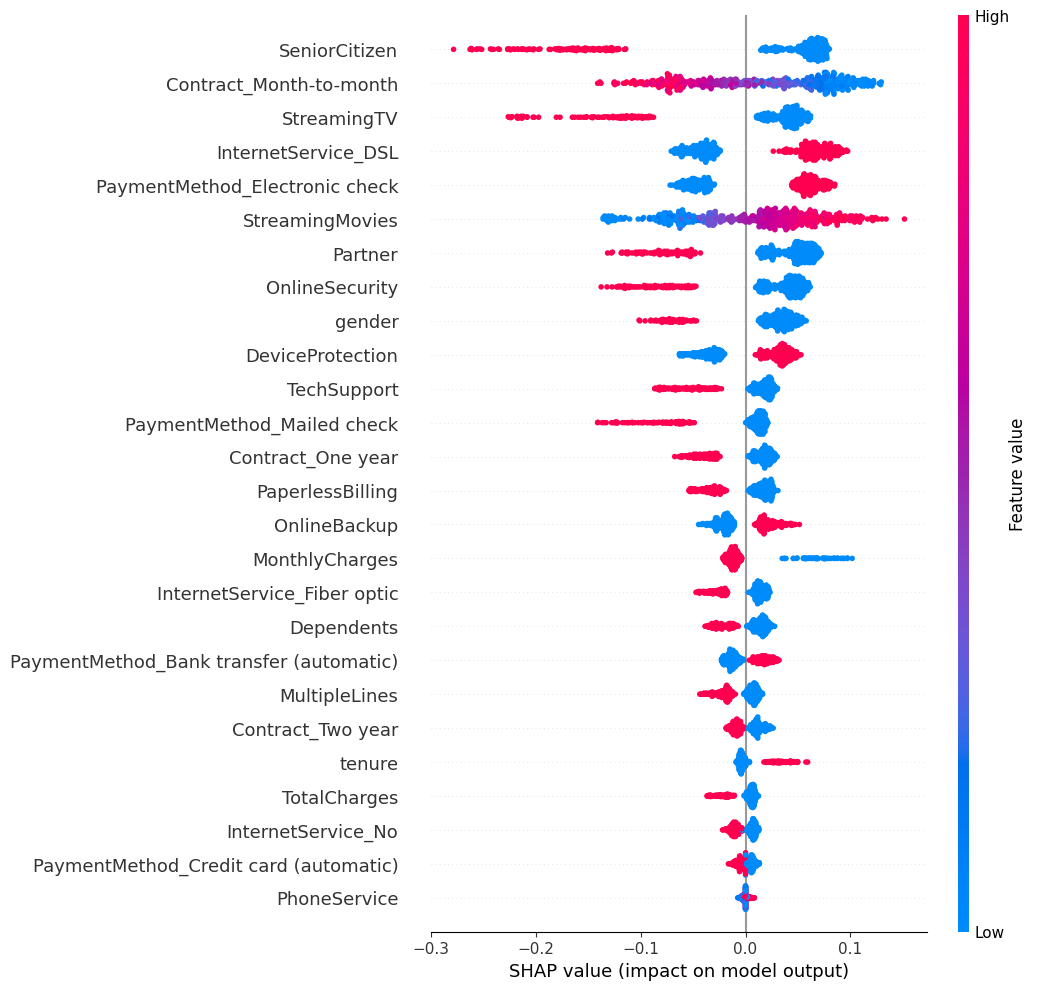

In [217]:
# Check the shape of shap_values and X_test_sap
print("Shape of SHAP values:", shap_values.shape)  # Should be (n_samples, n_features, n_outputs)
print("Shape of X_test_subset:", X_test_subset.shape)  # Should be (n_samples, n_features)

# Assuming it's a binary classification problem, extract the SHAP values for the first output
shap_exp = shap.Explanation(
    values=shap_values[:, :, 0],  # SHAP values for all instances (n_samples, n_features)
    base_values=explainer.expected_value[0],  # Base value for the first output class
    data=X_test_subset.values,  # All instances in the test set
    feature_names=feature_names
)

# Generate a beeswarm plot for all instances
shap.plots.beeswarm(shap_exp, max_display=len(feature_names))
plt.show()


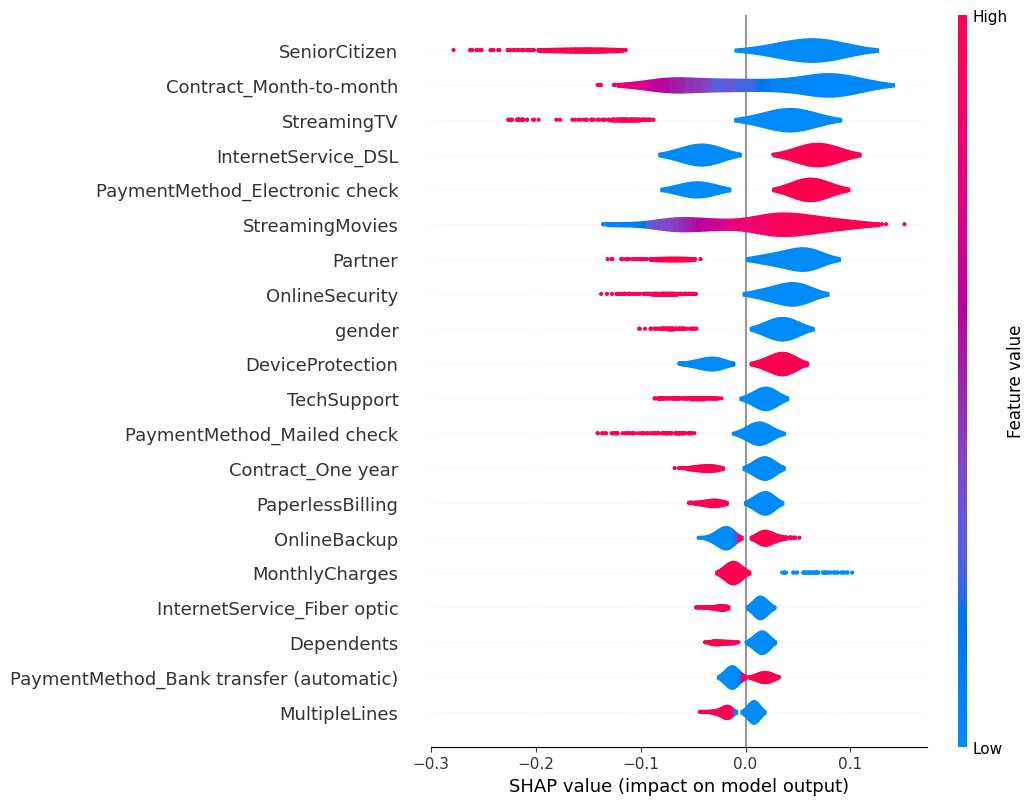

In [218]:
shap.plots.violin(shap_values_squeezed, X_test_subset, feature_names=feature_names)